# Deliverable 2: Bayesian Inference - Search for Lost Object

This notebook provides a complete Bayesian modeling workflow to locate an aircraft's lost object in a spatial grid. The workflow follows these steps:
1. **Prior Construction**: Using physical vectors and witness statements.
2. **Detection Model**: Defining the probability of detection based on effort and environmental conditions.
3. **Posterior Update**: Incorporating search outcomes using Bayes' Rule.
4. **Next Mission**: Proposing an optimal search strategy.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal

# Constants
Nx, Ny = 50, 35
x_E = np.array([7, 20])
v_plane = np.array([6.0, -3.5])
v_wind = np.array([-1.0, -1.5])
v_drift = np.array([0.5, -1.5])
budget = 230 # Example budget if not specified

# Load grid data
grid_df = pd.read_csv("grid_dataset.csv")
grid_df.head()

,cell_id,x,y,depth,roughness
0,0,0.5,0.5,0.000000,0.387418
1,1,1.5,0.5,0.037815,0.379730
2,2,2.5,0.5,0.075630,0.389246
3,3,3.5,0.5,0.113445,0.399845
4,4,4.5,0.5,0.151261,0.378569


## Task 1: Prior Construction

### Modeling the Displacement
The aircraft explosion occurred at $x_E$. Following the explosion, the object is subject to:
1. **Momentum**: The object continues in the direction of `v_plane` (Witness 1 & 2).
2. **Atmospheric/Maritime effects**: Wind and water drift act on the object as it falls and drifts.

We model the expected location $\mu$ as:
$$\mu = x_E + \alpha v_{plane} + \beta (v_{wind} + v_{drift})$$
We assume $\alpha = 3$ (reflecting the object's travel along the trajectory) and $\beta = 1$ for the combined environmental effects. 

### Probabilistic Distribution
We use a 2D Bivariate Normal distribution to represent our uncertainty. The covariance matrix $\Sigma$ is chosen to reflect higher uncertainty along the flight path (the object could have fallen earlier or later).

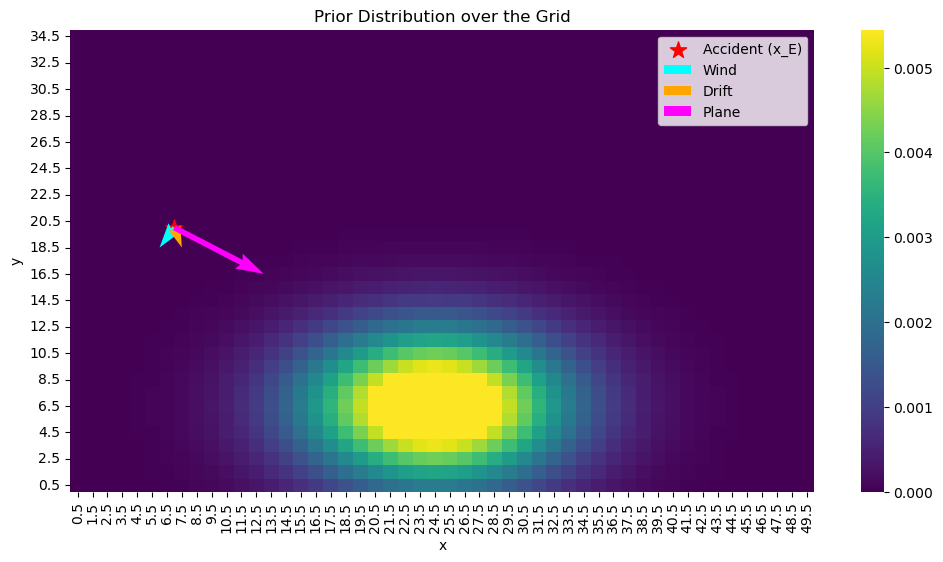

In [7]:
# Calculate mean location
alpha, beta = 3.0, 1.0
mu_prior = x_E + alpha * v_plane + beta * (v_wind + v_drift)

# Define Covariance Matrix (Higher spread along the trajectory)
sigma_x, sigma_y = 6.0, 4.0
cov_prior = np.array([[sigma_x**2, 0], [0, sigma_y**2]])

# Compute Prior for each cell
pos = np.dstack((grid_df['x'], grid_df['y']))
rv = multivariate_normal(mu_prior, cov_prior)
grid_df['prior'] = rv.pdf(pos)

# Normalize so they sum to 1
grid_df['prior'] /= grid_df['prior'].sum()

def plot_heatmap(df, column, title, show_vectors=False):
    pivot = df.pivot(index='y', columns='x', values=column)
    plt.figure(figsize=(12, 6))
    ax = sns.heatmap(pivot, cmap="viridis", robust=True)
    plt.title(title)
    if show_vectors:
        ax.scatter(x_E[0], x_E[1], color='red', marker='*', s=150, label='Accident (x_E)')
        ax.quiver(x_E[0], x_E[1], v_wind[0], v_wind[1], angles='xy', scale_units='xy', scale=1, color='cyan', label='Wind')
        ax.quiver(x_E[0], x_E[1], v_drift[0], v_drift[1], angles='xy', scale_units='xy', scale=1, color='orange', label='Drift')
        ax.quiver(x_E[0], x_E[1], v_plane[0], v_plane[1], angles='xy', scale_units='xy', scale=1, color='magenta', label='Plane')
        ax.legend()
    plt.gca().invert_yaxis()
    plt.show()

plot_heatmap(grid_df, 'prior', 'Prior Distribution over the Grid', show_vectors=True)

## Task 2: Detection Model

The conditional probability of detection $\rho_{tj}$ depends on the effort $e_t$ and the environmental variables of the cell ($d_j$ for depth and $r_j$ for roughness).

We propose an exponential detection model:
$$\rho_{tj} = 1 - \exp(-\lambda \cdot e_t \cdot \eta_j)$$
where $\eta_j$ is the search efficiency in cell $j$, modeled as:
$$\eta_j = \frac{1}{1 + \gamma_d d_j + \gamma_r r_j}$$

### Justification:
- **Effort**: As effort increases, the probability of detection increases, but with diminishing returns (exponential saturation).
- **Depth & Roughness**: These variables act as penalizing factors. Following the qualitative mission reports, deeper and rougher cells make the search harder, effectively reducing the impact of the effort $e_t$.

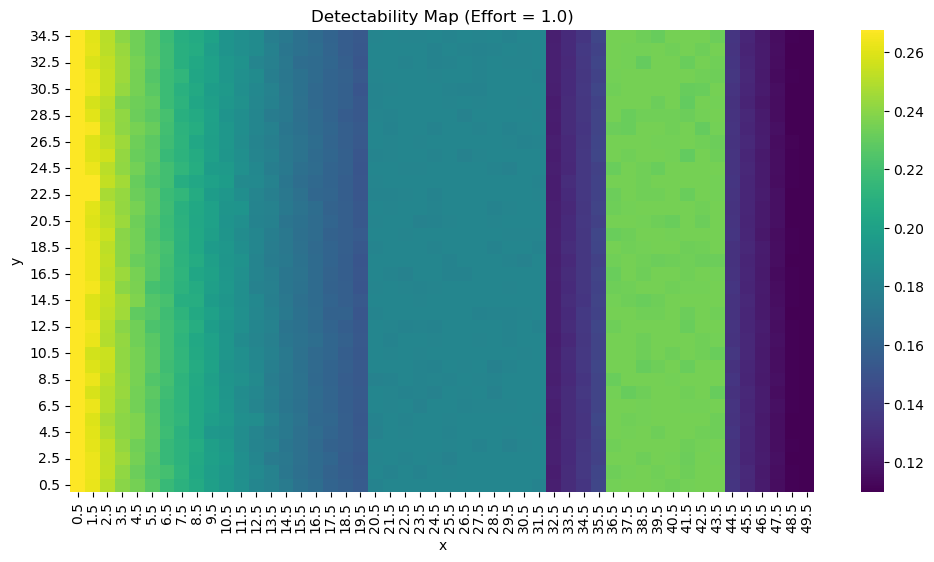

In [8]:
def calculate_detection_prob(effort, depth, roughness, lmbda=0.5, gamma_d=2.0, gamma_r=1.5):
    efficiency = 1 / (1 + gamma_d * depth + gamma_r * roughness)
    return 1 - np.exp(-lmbda * effort * efficiency)

# Visualize detectability map for a fixed effort e=1.0
grid_df['detectability_fixed_e'] = calculate_detection_prob(1.0, grid_df['depth'], grid_df['roughness'])
plot_heatmap(grid_df, 'detectability_fixed_e', 'Detectability Map (Effort = 1.0)')

## Task 3: Posterior Update

If a search mission $t$ in region $R_t$ with effort $e_t$ results in no detection ($s_t = 0$), we update the probability for each cell $j$ using Bayes' Rule:
$$P(Z=j | s_t=0) = \frac{P(s_t=0 | Z=j) P(Z=j)}{\sum_{k \in G} P(s_t=0 | Z=k) P(Z=k)}$$

Where the likelihood $P(s_t=0 | Z=j)$ is:
- $1 - \rho_{tj}$ if $j \in R_t$
- $1$ if $j \notin R_t$

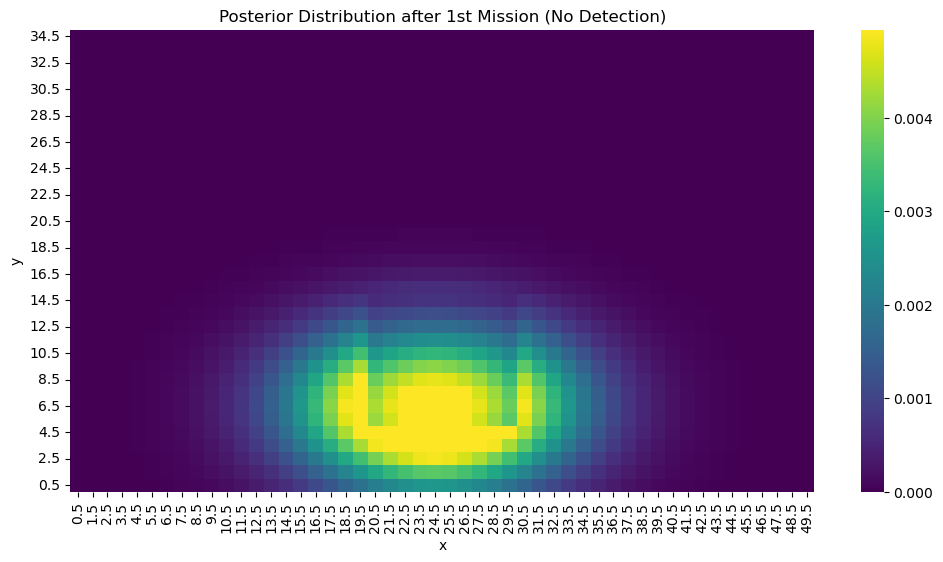

In [9]:
def update_posterior(df, x_min, x_max, y_min, y_max, effort):
    # Identify cells in the search region
    mask = (df['x'] >= x_min) & (df['x'] <= x_max) & (df['y'] >= y_min) & (df['y'] <= y_max)
    
    # Calculate conditional detection probability for these cells
    rho = calculate_detection_prob(effort, df.loc[mask, 'depth'], df.loc[mask, 'roughness'])
    
    # Likelihood of NO detection given object is in cell j
    likelihood_no_det = np.ones(len(df))
    likelihood_no_det[mask] = 1 - rho
    
    # Bayesian update
    df['posterior'] = df['prior'] * likelihood_no_det
    df['posterior'] /= df['posterior'].sum()
    return df

# Example: Search around the prior peak
grid_df = update_posterior(grid_df, x_min=20, x_max=30, y_min=5, y_max=15, effort=2.0)
plot_heatmap(grid_df, 'posterior', 'Posterior Distribution after 1st Mission (No Detection)')

## Task 4: Next Search Mission

To propose a new mission, we look for the region with the highest cumulative posterior probability. We define a rectangular search area that captures the 'peak' of the distribution.

In [10]:
def propose_mission(df, budget_remaining):
    # Find the cell with max posterior
    max_cell = df.loc[df['posterior'].idxmax()]
    
    # Define a rectangle around it (e.g., 6x6 units)
    x_center, y_center = max_cell['x'], max_cell['y']
    x_min, x_max = x_center - 3, x_center + 3
    y_min, y_max = y_center - 3, y_center + 3
    
    # Count cells
    n_cells = ((df['x'] >= x_min) & (df['x'] <= x_max) & (df['y'] >= y_min) & (df['y'] <= y_max)).sum()
    
    # Propose effort based on budget
    proposed_effort = min(2.0, budget_remaining / n_cells)
    
    return {
        "x_min": x_min, "x_max": x_max,
        "y_min": y_min, "y_max": y_max,
        "effort": proposed_effort,
        "cost": proposed_effort * n_cells
    }

next_mission = propose_mission(grid_df, budget_remaining=1000)
print("Proposed Next Mission:", next_mission)

Proposed Next Mission: {'x_min': np.float64(21.5), 'x_max': np.float64(27.5), 'y_min': np.float64(1.5), 'y_max': np.float64(7.5), 'effort': 2.0, 'cost': np.float64(98.0)}


## Task 5: Discussion

### Strengths
- **Physical Grounding**: The prior is not arbitrary; it is derived from the known kinematics of the accident.
- **Environmental Awareness**: The detection model explicitly penalizes difficult search conditions (depth/roughness), preventing wasted effort in 'blind' areas.

### Limitations
- **Gaussian Assumption**: We assume a simple Normal distribution for displacement, which might not capture complex aerodynamic behaviors during the fall.
- **Fixed Parameters**: The coefficients $\lambda, \gamma_d, \gamma_r$ are currently estimated qualitatively. Calibrating these with more historical data would improve accuracy.

### Future Improvements
- Use a **Monte Carlo simulation** of the object's fall to create a more non-parametric prior.
- Implement a **multi-mission optimizer** that plans a sequence of searches to minimize the expected time to detection.